##Importing all the libraries

In [24]:
from sklearn.preprocessing import OneHotEncoder
from flask import Flask, render_template, request
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#from scipy.stats import zscore
# from sklearn.ensemble import StackingRegressor
from sklearn.neural_network import MLPRegressor
# from sklearn.svm import SVR
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [25]:
def posix_time(dt):
    return (dt - datetime(1970, 1, 1)) / timedelta(seconds=1)



#importing the dataset




In [26]:
data = pd.read_csv('Train.csv')

#taking the required features or columns
Collecting the data


In [27]:
data = data.sort_values(
    by=['date_time'], ascending=True).reset_index(drop=True)
last_n_hours = [1, 2, 3, 4, 5, 6]
for n in last_n_hours:
    data[f'last_{n}_hour_traffic'] = data['traffic_volume'].shift(n)
data = data.dropna().reset_index(drop=True)
data.loc[data['is_holiday'] != 'None', 'is_holiday'] = 1
data.loc[data['is_holiday'] == 'None', 'is_holiday'] = 0
data['is_holiday'] = data['is_holiday'].astype(int)

data['date_time'] = pd.to_datetime(data['date_time'])
data['hour'] = data['date_time'].map(lambda x: int(x.strftime("%H")))
data['month_day'] = data['date_time'].map(lambda x: int(x.strftime("%d")))
data['weekday'] = data['date_time'].map(lambda x: x.weekday()+1)
data['month'] = data['date_time'].map(lambda x: int(x.strftime("%m")))
data['year'] = data['date_time'].map(lambda x: int(x.strftime("%Y")))
data.to_csv("traffic_volume_data.csv", index=None)

   is_holiday  air_pollution_index  humidity  wind_speed  wind_direction  \
0           1                   13        94           3              78   
1           1                  201        93           1              90   
2           1                  196        81           1              70   
3           1                  104        88           3             303   
4           1                  154        63           3             137   

   visibility_in_miles  dew_point  temperature  rain_p_h  snow_p_h  ...  \
0                    5          5       269.09      0.00       0.0  ...   
1                    4          4       277.72      0.00       0.0  ...   
2                    6          6       293.17      1.52       0.0  ...   
3                    2          2       281.96      0.00       0.0  ...   
4                    2          2       268.24      0.00       0.0  ...   

   last_2_hour_traffic  last_3_hour_traffic  last_4_hour_traffic  \
0               2741.0  

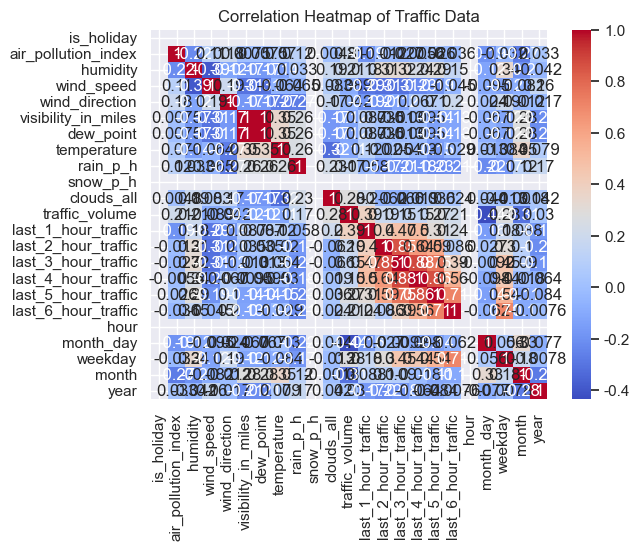

In [28]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style and Matplotlib default font properties
sns.set()  # Seaborn default style
plt.rcParams['font.sans-serif'] = ['Arial']  # Use Arial or any other available font
plt.rcParams['axes.unicode_minus'] = False    # To ensure minus signs display correctly

# Ignore warnings
warnings.filterwarnings('ignore')

# Load the dataset
data = pd.read_csv("traffic_volume_data.csv")

# Get the total number of rows in the dataset
num_rows = data.shape[0]

# Ensure we sample no more than the total number of rows available
sample_size = min(100, num_rows)

# Sample the dataset
data = data.sample(sample_size).reset_index(drop=True)

# Define columns for processing
label_columns = ['weather_type', 'weather_description']
numeric_columns = ['is_holiday', 'temperature', 'weekday', 'hour', 'month_day', 'year', 'month']

# Drop non-numeric columns before calculating correlations
data_numeric = data.drop(columns=['date_time', 'weather_type', 'weather_description'])

# Example: Display first few rows of the numeric data
print(data_numeric.head())

# Optional: Use Seaborn or Matplotlib for visualization
# Correlation heatmap for numeric columns
sns.heatmap(data_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Traffic Data")
plt.show()


In [29]:
features = numeric_columns+label_columns
X = data[features]
X.head()

,is_holiday,temperature,weekday,hour,month_day,year,month,weather_type,weather_description
0,1,269.09,5,0,25,2015,12,Snow,light snow
1,1,277.72,1,0,14,2013,10,Clear,Sky is Clear
2,1,293.17,1,0,5,2016,9,Rain,moderate rain
3,1,281.96,5,0,11,2016,11,Clear,sky is clear
4,1,268.24,4,0,28,2013,11,Clouds,broken clouds


In [30]:
X.shape


(43, 9)

In [31]:
from functools import reduce

# Function to get unique elements
def unique(list1):
    ans = reduce(lambda re, x: re + [x] if x not in re else re, list1, [])
    print(ans)

# Extract weather type and description columns
n1 = data['weather_type']
n2 = data['weather_description']

# Call the unique function for both weather columns to print unique values
unique(n1)
unique(n2)

# List of known weather types and descriptions
n1features = ['Rain', 'Clouds', 'Clear', 'Snow', 'Mist',
              'Drizzle', 'Haze', 'Thunderstorm', 'Fog', 'Smoke', 'Squall']
n2features = ['light rain', 'few clouds', 'Sky is Clear', 'light snow', 'sky is clear', 'mist', 
              'broken clouds', 'moderate rain', 'drizzle', 'overcast clouds', 'scattered clouds', 
              'haze', 'proximity thunderstorm', 'light intensity drizzle', 'heavy snow', 
              'heavy intensity rain', 'fog', 'heavy intensity drizzle', 'shower snow', 'snow', 
              'thunderstorm with rain', 'thunderstorm with heavy rain', 'thunderstorm with light rain', 
              'proximity thunderstorm with rain', 'thunderstorm with drizzle', 'smoke', 'thunderstorm', 
              'proximity shower rain', 'very heavy rain', 'proximity thunderstorm with drizzle', 
              'light rain and snow', 'light intensity shower rain', 'SQUALLS', 'shower drizzle', 
              'thunderstorm with light drizzle']

# Prepare lists to store numeric mappings
n11 = []
n22 = []

# Loop through the length of the data instead of hardcoding 10000
data_length = len(n1)

for i in range(data_length):
    # For weather_type
    if n1[i] not in n1features:
        n11.append(0)
    else:
        n11.append(n1features.index(n1[i]) + 1)  # Add 1 for a non-zero index

    # For weather_description
    if n2[i] not in n2features:
        n22.append(0)
    else:
        n22.append(n2features.index(n2[i]) + 1)  # Add 1 for a non-zero index

# Replace the original columns with numeric features
data['weather_type'] = n11
data['weather_description'] = n22

# Verify that the transformation worked
print(data.head())


['Snow', 'Clear', 'Rain', 'Clouds', 'Haze', 'Mist', 'Thunderstorm']
['light snow', 'Sky is Clear', 'moderate rain', 'sky is clear', 'broken clouds', 'overcast clouds', 'haze', 'mist', 'few clouds', 'scattered clouds', 'light rain', 'proximity thunderstorm']
    date_time  is_holiday  air_pollution_index  humidity  wind_speed  \
0  2015-12-25           1                   13        94           3   
1  2013-10-14           1                  201        93           1   
2  2016-09-05           1                  196        81           1   
3  2016-11-11           1                  104        88           3   
4  2013-11-28           1                  154        63           3   

   wind_direction  visibility_in_miles  dew_point  temperature  rain_p_h  ...  \
0              78                    5          5       269.09      0.00  ...   
1              90                    4          4       277.72      0.00  ...   
2              70                    6          6       293.17    

#Data Preparation

In [32]:
features = numeric_columns+label_columns
target = ['traffic_volume']
X = data[features]
y = data[target]

In [33]:
X.head(6)

,is_holiday,temperature,weekday,hour,month_day,year,month,weather_type,weather_description
0,1,269.09,5,0,25,2015,12,4,4
1,1,277.72,1,0,14,2013,10,3,3
2,1,293.17,1,0,5,2016,9,1,8
3,1,281.96,5,0,11,2016,11,3,5
4,1,268.24,4,0,28,2013,11,2,7
5,1,275.44,1,0,11,2013,11,2,7


[[<Axes: title={'center': 'is_holiday'}>
  <Axes: title={'center': 'temperature'}>
  <Axes: title={'center': 'weekday'}>]
 [<Axes: title={'center': 'hour'}> <Axes: title={'center': 'month_day'}>
  <Axes: title={'center': 'year'}>]
 [<Axes: title={'center': 'month'}>
  <Axes: title={'center': 'weather_type'}>
  <Axes: title={'center': 'weather_description'}>]]


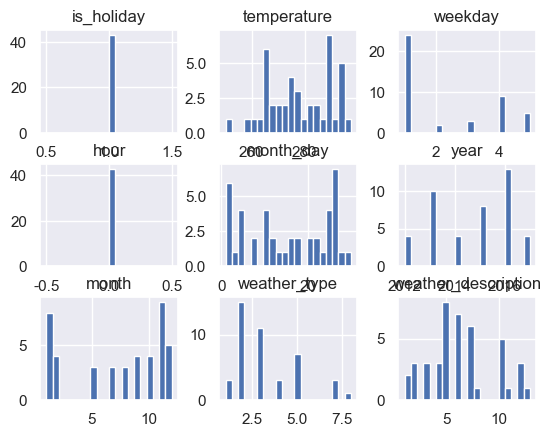

In [34]:
print(data[features].hist(bins=20,))

In [35]:
# data['traffic_volume'].hist(bins=20)

#Feature Scaling

In [36]:
x_scaler = MinMaxScaler()
X = x_scaler.fit_transform(X)
y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(y).flatten()
warnings.filterwarnings('ignore')

In [37]:
print(X[:5])

[[0.         0.40080372 1.         0.         0.82758621 0.6
  1.         0.42857143 0.25      ]
 [0.         0.58333333 0.         0.         0.44827586 0.2
  0.81818182 0.28571429 0.16666667]
 [0.         0.91010998 0.         0.         0.13793103 0.8
  0.72727273 0.         0.58333333]
 [0.         0.67301184 1.         0.         0.34482759 0.8
  0.90909091 0.28571429 0.33333333]
 [0.         0.38282572 0.75       0.         0.93103448 0.2
  0.90909091 0.14285714 0.5       ]]


#Visualization

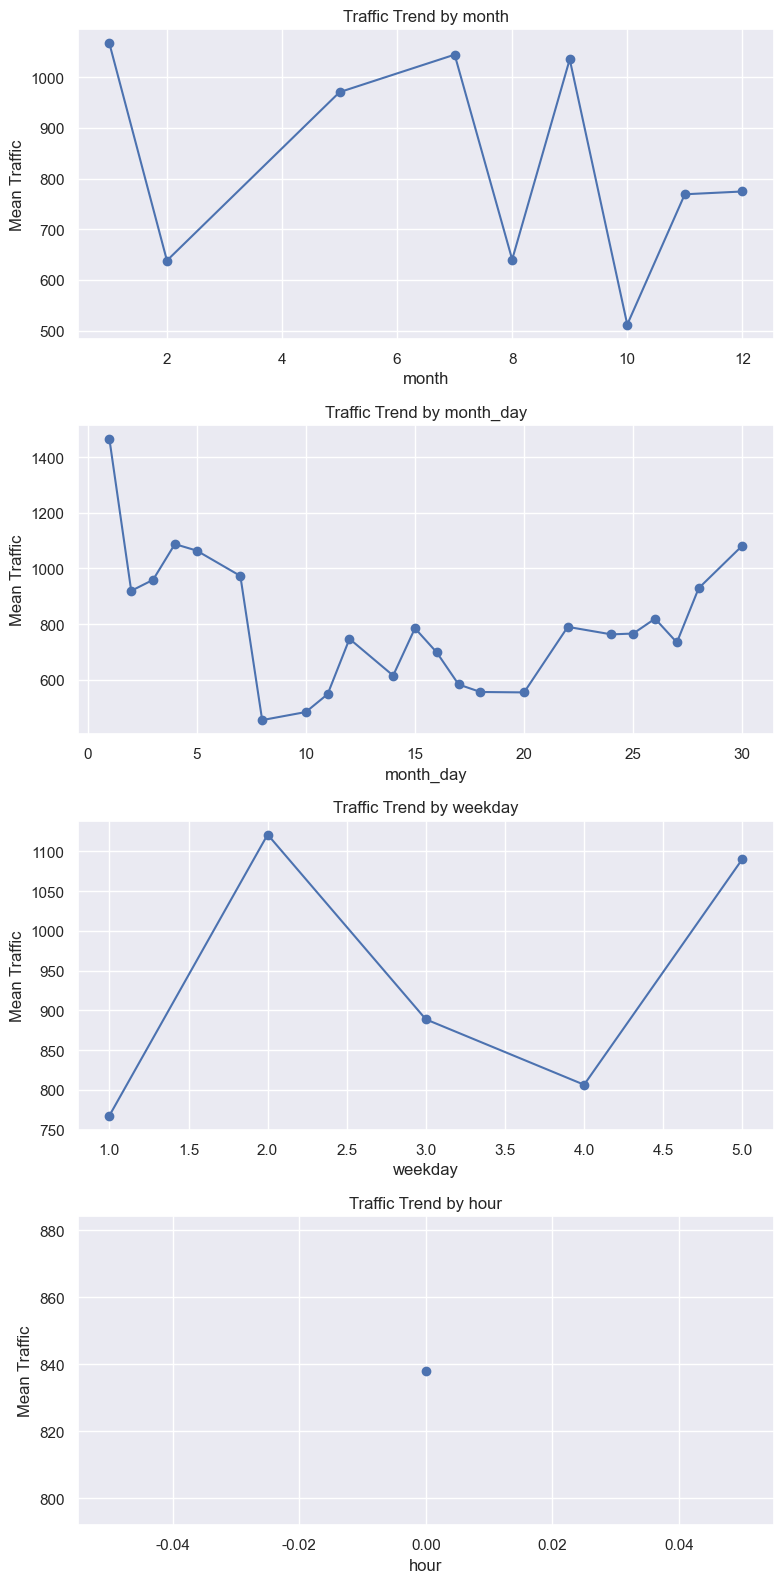

In [38]:
metrics = ['month', 'month_day', 'weekday', 'hour']
fig = plt.figure(figsize=(8, 4*len(metrics)))
for i, metric in enumerate(metrics):
	ax = fig.add_subplot(len(metrics), 1, i+1)
	ax.plot(data.groupby(metric)['traffic_volume'].mean(), '-o')
	ax.set_xlabel(metric)
	ax.set_ylabel("Mean Traffic")
	ax.set_title(f"Traffic Trend by {metric}")
plt.tight_layout()
plt.show()

#Train the Model

In [39]:
regr = MLPRegressor(random_state=1, max_iter=500).fit(X, y)
new = []
print('predicted output :=',regr.predict(X[:10]))
print('Actual output :=',y[:10])

predicted output := [0.29711827 0.18917892 0.4089717  0.26866642 0.38251957 0.25453936
 0.31946277 1.06049241 0.25145872 0.18453359]
Actual output := [0.41493384 0.15122873 0.57561437 0.11058601 0.44801512 0.0557656
 0.3289225  1.         0.22967864 0.02741021]


In [40]:
# error eval
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.2)
y_pred = regr.predict(testX)
print('Mean Absolute Error:', mean_absolute_error(testY, y_pred))
##############################

Mean Absolute Error: 0.11244189396877063


In [41]:
print(features)

['is_holiday', 'temperature', 'weekday', 'hour', 'month_day', 'year', 'month', 'weather_type', 'weather_description']


In [42]:
data[features].head(5)

,is_holiday,temperature,weekday,hour,month_day,year,month,weather_type,weather_description
0,1,269.09,5,0,25,2015,12,4,4
1,1,277.72,1,0,14,2013,10,3,3
2,1,293.17,1,0,5,2016,9,1,8
3,1,281.96,5,0,11,2016,11,3,5
4,1,268.24,4,0,28,2013,11,2,7


#User input

In [43]:
ip=[0,89,2,288.28,1,9,2,2012,10]
ip = x_scaler.transform([ip])
out=regr.predict(ip)
print('Before inverse Scaling :',out)

Before inverse Scaling : [183.32785861]


In [44]:
y_pred = y_scaler.inverse_transform([out])
print('Traffic Volume : ',y_pred)

Traffic Volume :  [[194415.87440684]]


In [45]:
if(y_pred<=1000):
  print("No Traffic ")
elif y_pred>1000 and y_pred<=3000:
  print("Busy or Normal Traffic")
elif y_pred>3000 and y_pred<=5500:
  print("heavy Traffic")
else:
  print("Worst case")

Worst case


#Evaluating Metrics 

In [46]:
# def relative_absolute_error(true, pred):
#     true_mean = np.mean(true)
#     squared_error_num = np.sum(np.abs(true - pred))
#     squared_error_den = np.sum(np.abs(true - true_mean))
#     rae_loss = squared_error_num / squared_error_den
#     return rae_loss
# def mean_bias_error(true, pred):
#     bias_error = true - pred
#     mbe_loss = np.mean(np.sum(diff) / true.size)
#     return mbe_loss
# def mean_absolute_percentage_error(true, pred):
#     abs_error = (np.abs(true - pred)) / true
#     sum_abs_error = np.sum(abs_error)
#     mape_loss = (sum_abs_error / true.size) * 100
#     return mape_loss
# def mean_squared_error(true, pred):
#     squared_error = np.square(true - pred) 
#     sum_squared_error = np.sum(squared_error)
#     mse_loss = sum_squared_error / true.size
#     return mse_loss
# def root_mean_squared_error(true, pred):
#     squared_error = np.square(true - pred) 
#     sum_squared_error = np.sum(squared_error)
#     rmse_loss = np.sqrt(sum_squared_error / true.size)
#     return rmse_loss